In [1]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from numpy import pi as π, sin,cos

In [2]:
filename_mixed = "./c_CHSH_mix/CHSH_fixed_a0.25_b0.25_Pt_0.9107_100_points_1.5E+04_states_SIM_29_05_2026_13_40_38.csv"
filename_entangled= "./b_CHSH_ent/CHSH_fixed_a0.25_b0.25_Pt_0.9107_100_points_1.5E+04_states_SIM_29_05_2026_14_22_29.csv"
filename_PCorr_T = "./a_Pcorr/CORR_fixed_a0.5_b0.5_Pt_0.9107_100_points_1.5E+04_states_SIM_29_05_2026_16_27_35.csv"
pcorr=pd.read_csv(filename_PCorr_T, header=None).to_numpy().flatten()
chsh_mixed = pd.read_csv(filename_mixed, header=None).to_numpy().flatten()
chsh_ent = pd.read_csv(filename_entangled, header=None).to_numpy().flatten()

In [3]:
def analytical_CHSH(theta_FSS, Pt=1.0):
    
    """ Analytical model for CHSH quantity """
    if Pt == 1.0:
        P_HH = P_HV = P_VH = P_VV = 0.0
    else:
        P_HH = 0.0030
        P_HV = 0.0138
        P_VH = 0.0278
        P_VV = 0.0447
    
    return np.sqrt(2)*(Pt*(cos(theta_FSS) + 1) + P_HH + P_VV - P_HV - P_VH)
    
def model_noise(θ, α, β, Pt=1.0):
    
    # 2. Probability assignment without dynamic re-scaling
    if Pt == 1.0:
        P_HH = P_HV = P_VH = P_VV = 0.0
    else:
        P_HH = 0.0030
        P_HV = 0.0138
        P_VH = 0.0278  # Using the corrected value
        P_VV = 0.0447
    
    # Pre-compute trigonometric values
    C_a = cos(α)
    S_a = sin(α)
    C_ab = cos(α + β)
    S_ab = sin(α + β)
    C_theta = cos(θ)
    
    # Term 1: Pt * (1/2) * [...]
    term1 = (Pt / 2.0) * (
        C_a**4 + S_a**4 + 2 * (S_a**2) * (C_a**2) * C_theta +
        C_ab**4 + S_ab**4 + 2 * (S_ab**2) * (C_ab**2) * C_theta
    )
    
    # Term 2: ((P_HH + P_VV)/2) * [...]
    term2 = ((P_HH + P_VV) / 2.0) * (
        C_a**4 + S_a**4 + C_ab**4 + S_ab**4
    )
    
    # Term 3: (P_HV + P_VH) * [...]
    term3 = (P_HV + P_VH) * (
        (C_a**2) * (S_a**2) + (C_ab**2) * (S_ab**2)
    )
    
    return term1 + term2 + term3

In [4]:
def ϵ(y_true:np.ndarray, y_pred:np.ndarray):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    # Manually compute epsilon: Sum((y_i - y_hat_i)^2) / Sum((y_i - y_mean)^2)
    sum_squared_residuals = np.sum((y_true_flat - y_pred_flat) ** 2)
    total_sum_squares = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
    return sum_squared_residuals / total_sum_squares

In [5]:
N_data = 100

# 4. Create the corresponding θ
θ = np.linspace(0, 2 * np.pi, N_data)

# 1. Variables for formatting quantities outside figure
tick_font_size = 20
legend_font_size = 20
axes_label_font_size = 30
title_fontsize = 30
font_family = "Arial"

line_w= 8
limit_w=2
line_c = 'rgb(237, 7, 7)'
line_color='rgb(8, 99, 117)'

In [6]:
print(f"{ϵ(y_pred=model_noise(θ,π/4,π/4,Pt=1.0),y_true=pcorr)}\n")
print(f"{ϵ(y_pred=model_noise(θ,π/2,π/2,Pt=1.0),y_true=pcorr)}\n")
print(f"{ϵ(y_pred=model_noise(θ,π/8,π/8,Pt=1.0),y_true=pcorr)}\n")

0.001081815221312489

2.937704478150666

0.7350184574978503



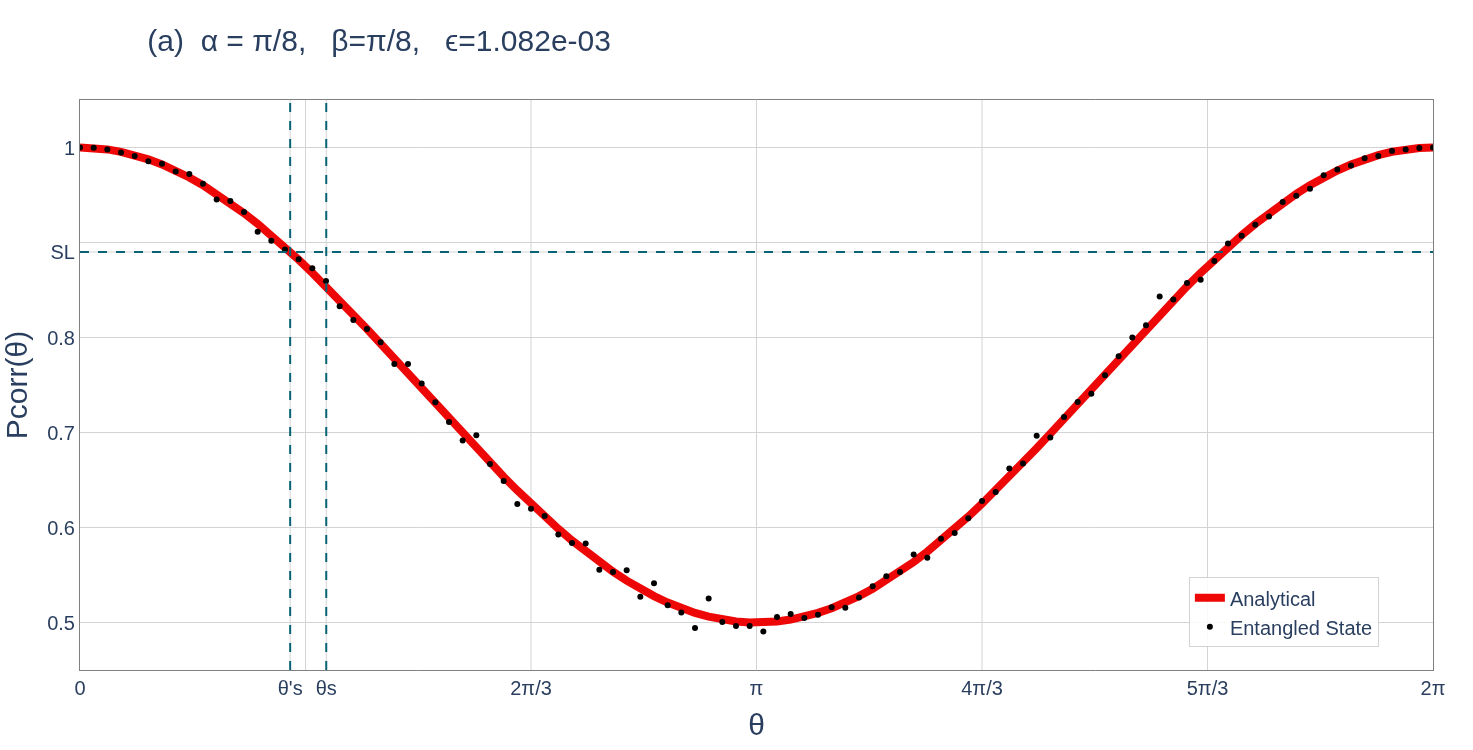

In [7]:
ϵ_val = ϵ(y_pred=model_noise(θ,π/4,π/4,Pt=1.0),y_true=pcorr)

θc = 0.976
θs = 0.364*π
fig_a = go.Figure()
##############         LIMITS         ##############

fig_a.add_vline(x=θc, line_width=limit_w, line_dash="dash", line_color=line_color)
fig_a.add_vline(x=θs, line_width=limit_w, line_dash="dash", line_color=line_color)
fig_a.add_hline(y=0.89, line_width=limit_w, line_dash="dash", line_color=line_color)
##############         Analytical         ##############
fig_a.add_trace(go.Scatter(
    x=θ, 
    y=model_noise(θ,π/4,π/4,Pt=1.0), 
    mode='lines', 
    name='Analytical',
    line=dict(color=line_c, width=line_w)
))
##############         Experimental         ##############
fig_a.add_trace(go.Scatter(
    x=θ, 
    y=pcorr, 
    mode='markers', 
    name='Entangled State',
    line=dict(color='black', width=3)
))

##############         LAYOUT         ##############

fig_a.update_layout(
    xaxis=dict(
        title=dict(
            text='θ',
            font=dict(size=axes_label_font_size, family=font_family)
        ), 
        tickfont=dict(size=tick_font_size, family=font_family),                    
        tickmode='array',
        tickvals=[0,θs, np.pi/3, θc, 2*np.pi/3, np.pi, 4*np.pi/3, 5*np.pi/3, 2*np.pi],
        ticktext=['0', 'θs' ,'', "θ's", '2π/3', 'π', '4π/3', '5π/3', '2π'],
        range=[0, 2*π],
        showgrid=True, gridcolor='lightgray',zeroline=True,
        showline=True, linewidth=1, linecolor='gray', mirror=True
    ),
    yaxis=dict(
        title=dict(
            text='Pcorr(θ)',  # Update y-axis label as needed
            font=dict(size=axes_label_font_size, family=font_family)
        ),
        tickfont=dict(size=tick_font_size, family=font_family),
        tickmode='array',
        tickvals=[0,0.4,0.5,0.6,0.7,0.8,0.89,0.9,1],
        ticktext=['0','0.4','0.5','0.6','0.7','0.8','SL','','1'],
        range=[0.45,1.05],
        showgrid=True, gridcolor='lightgray',
        showline=True, linewidth=1, linecolor='gray', mirror=True,
    ),
    title=dict(
        text=f"(a)\t\tα = π/8, \t\tβ=π/8, \t\tϵ={ϵ_val:1.3e}",
        font=dict(size=title_fontsize, family=font_family),
        x=0.1, 
        y=0.96
    ),
    autosize=False,
    width=750,
    height=750,
    plot_bgcolor='white',
        paper_bgcolor='white',
        
        # --- NEW LEGEND POSITIONING ---
    legend=dict(
        font=dict(family=font_family, size=legend_font_size),
        yanchor="bottom",
        y=0.04,             # 5% from the bottom
        xanchor="right",
        x=0.96,             # 95% to the right
        bgcolor="rgba(255, 255, 255, 0.85)", # Semi-transparent white background
        bordercolor="lightgray",             # Optional border to frame it cleanly
        borderwidth=1
    ),
    margin=dict(l=80, r=40, t=100, b=80) # Added margin so large labels are not cut off
)

# Display the figure
#fig_a.show()
#"""

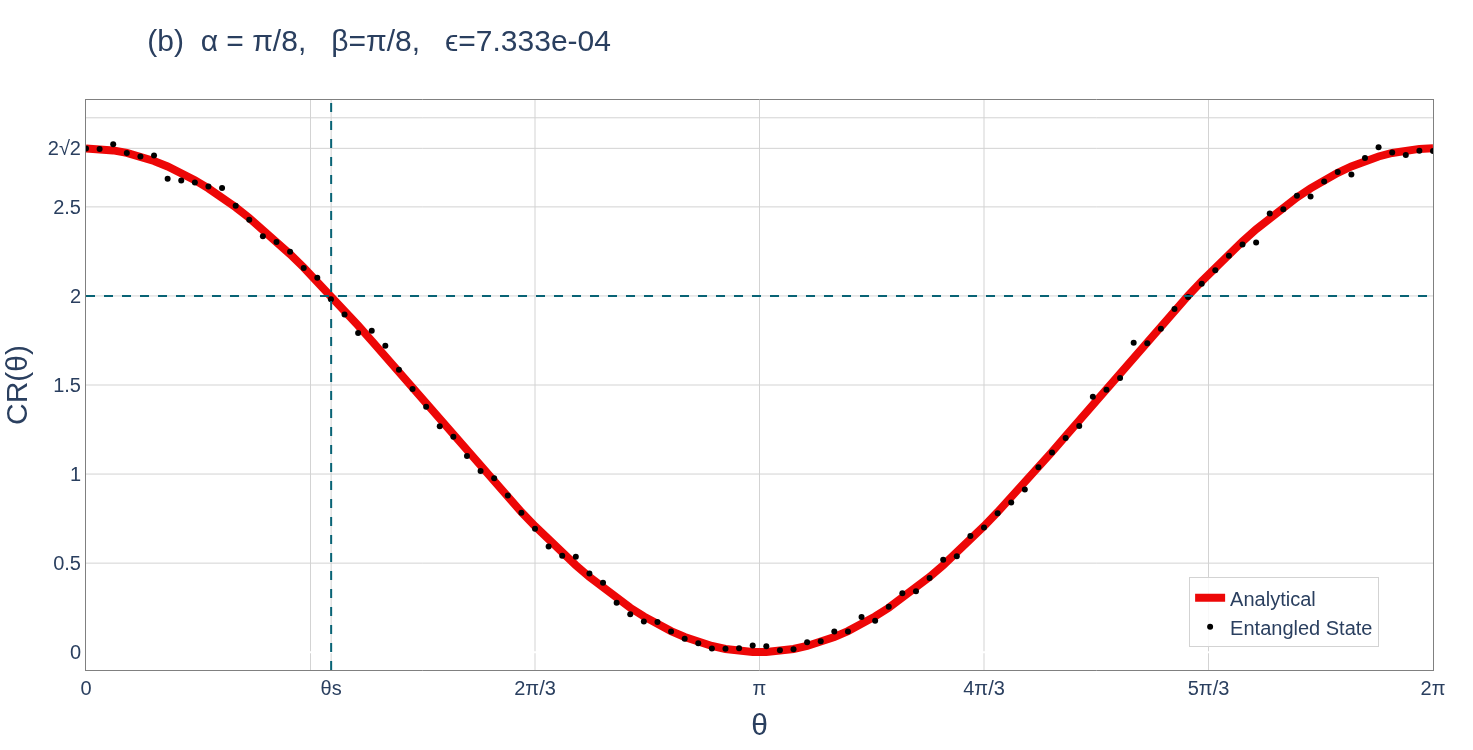

In [8]:
ϵ_val = ϵ(y_pred=analytical_CHSH(theta_FSS=θ,Pt=1.0),y_true=chsh_ent)
θs = 0.364*π
fig_b = go.Figure()
##############         LIMITS         ##############
fig_b.add_hline(y=2, line_width=limit_w, line_dash="dash", line_color=line_color)
fig_b.add_vline(x=θs, line_width=limit_w, line_dash="dash", line_color=line_color)

##############         Analytical         ##############
fig_b.add_trace(go.Scatter(
    x=θ, 
    y=analytical_CHSH(theta_FSS=θ,Pt=1.0), 
    mode='lines', 
    name='Analytical',
    line=dict(color=line_c, width=line_w)
))
##############         Experimental         ##############
fig_b.add_trace(go.Scatter(
    x=θ, 
    y=np.abs(chsh_ent), 
    mode='markers', 
    name='Entangled State',
    line=dict(color='black', width=3)
))

##############         LAYOUT         ##############

fig_b.update_layout(
    xaxis=dict(
        title=dict(
            text='θ',
            font=dict(size=axes_label_font_size, family=font_family)
        ), 
        tickfont=dict(size=tick_font_size, family=font_family),                    
        tickmode='array',
        tickvals=[0, np.pi/3, θs, 2*np.pi/3, np.pi, 4*np.pi/3, 5*np.pi/3, 2*np.pi],
        ticktext=['0', '', 'θs', '2π/3', 'π', '4π/3', '5π/3', '2π'],
        range=[0, 2*π],
        showgrid=True, gridcolor='lightgray',zeroline=True,
        showline=True, linewidth=1, linecolor='gray', mirror=True
    ),
    yaxis=dict(
        title=dict(
            text='CR(θ)',  # Update y-axis label as needed
            font=dict(size=axes_label_font_size, family=font_family)
        ),
        tickfont=dict(size=tick_font_size, family=font_family),
        tickmode='array',
        tickvals=[0,0.5,1,1.5,2,2.5,2*np.sqrt(2),3],
        ticktext=['0', '0.5', '1','1.5','2','2.5','2√2',''],
        range=[-0.1,3.1],
        showgrid=True, gridcolor='lightgray',
        showline=True, linewidth=1, linecolor='gray', mirror=True,
    ),
    title=dict(
        text=f"(b)\t\tα = π/8, \t\tβ=π/8, \t\tϵ={ϵ_val:1.3e}",
        font=dict(size=title_fontsize, family=font_family),
        x=0.1, 
        y=0.96
    ),
    autosize=False,
    width=750,
    height=750,
    plot_bgcolor='white',
        paper_bgcolor='white',
        
        # --- NEW LEGEND POSITIONING ---
    legend=dict(
        font=dict(family=font_family, size=legend_font_size),
        yanchor="bottom",
        y=0.04,             # 5% from the bottom
        xanchor="right",
        x=0.96,             # 95% to the right
        bgcolor="rgba(255, 255, 255, 0.85)", # Semi-transparent white background
        bordercolor="lightgray",             # Optional border to frame it cleanly
        borderwidth=1
    ),
    margin=dict(l=80, r=40, t=100, b=80) # Added margin so large labels are not cut off
)

# Display the figure
#fig_b.show()

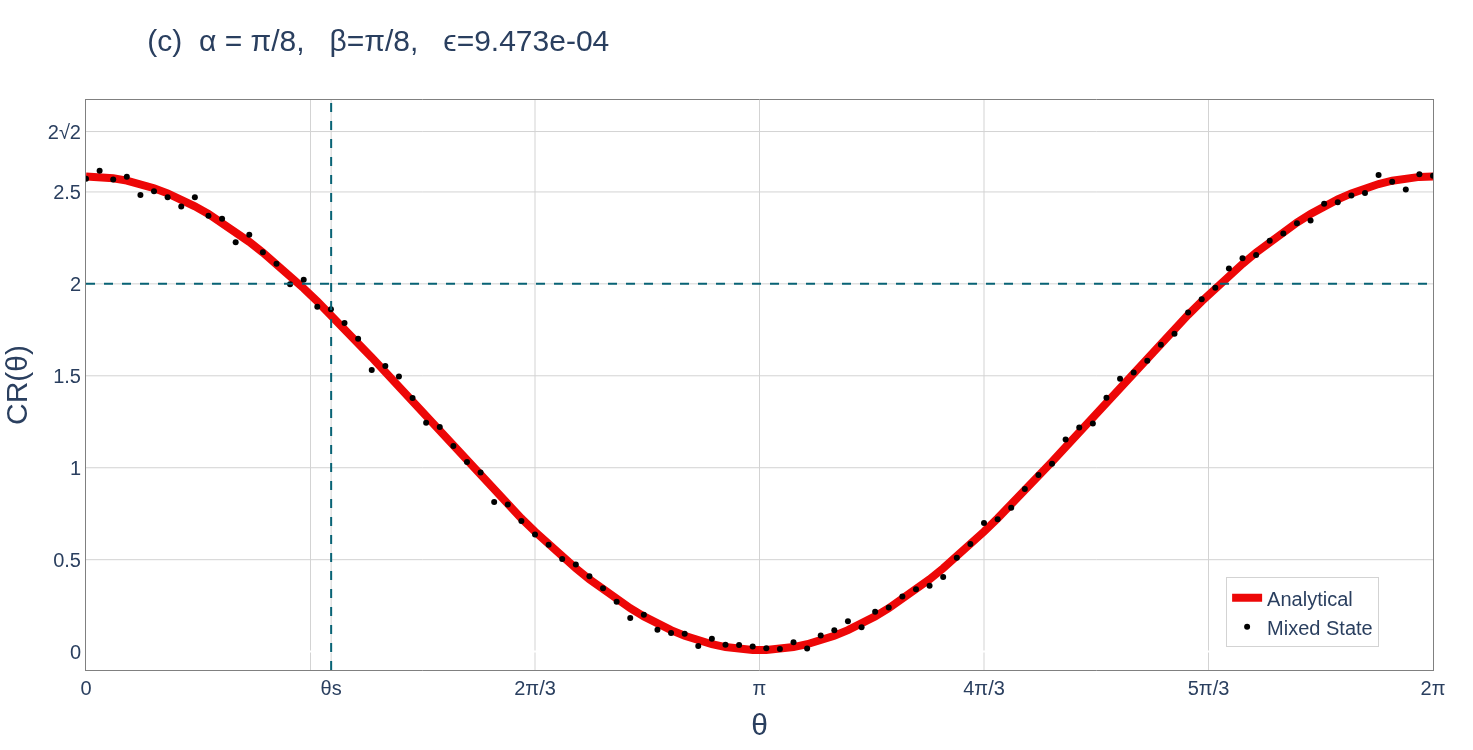

In [9]:
ϵ_val = ϵ(y_pred=analytical_CHSH(theta_FSS=θ,Pt=0.9107),y_true=chsh_mixed)
θs = 0.364*π
fig_c = go.Figure()
##############         LIMITS         ##############
##############         LIMITS         ##############

#fig_c.add_hline(y=2, line_width=limit_w, line_dash="dash", line_color="rgb(97, 63, 117)")
#fig_c.add_vline(x=θs, line_width=limit_w, line_dash="dash", line_color="rgb(97, 63, 117)")
fig_c.add_hline(y=2, line_width=limit_w, line_dash="dash", line_color=line_color)
fig_c.add_vline(x=θs, line_width=limit_w, line_dash="dash", line_color=line_color)


##############         Analytical         ##############
fig_c.add_trace(go.Scatter(
    x=θ, 
    y=analytical_CHSH(theta_FSS=θ,Pt=0.9107), 
    mode='lines', 
    name='Analytical',
    line=dict(color=line_c, width=line_w)
))
##############         Experimental         ##############
fig_c.add_trace(go.Scatter(
    x=θ, 
    y=np.abs(chsh_mixed), 
    mode='markers', 
    name='Mixed State',
    line=dict(color='black', width=3)
))

##############         LAYOUT         ##############

fig_c.update_layout(
    xaxis=dict(
        title=dict(
            text='θ',
            font=dict(size=axes_label_font_size, family=font_family)
        ), 
        tickfont=dict(size=tick_font_size, family=font_family),                    
        tickmode='array',
        tickvals=[0, np.pi/3, θs, 2*np.pi/3, np.pi, 4*np.pi/3, 5*np.pi/3, 2*np.pi],
        ticktext=['0', '', 'θs', '2π/3', 'π', '4π/3', '5π/3', '2π'],
        range=[0, 2*π],
        showgrid=True, gridcolor='lightgray',zeroline=True,
        showline=True, linewidth=1, linecolor='gray', mirror=True
    ),
    yaxis=dict(
        title=dict(
            text='CR(θ)',  # Update y-axis label as needed
            font=dict(size=axes_label_font_size, family=font_family)
        ),
        tickfont=dict(size=tick_font_size, family=font_family),
        tickmode='array',
        tickvals=[0,0.5,1,1.5,2,2.5,2*np.sqrt(2),3],
        ticktext=['0', '0.5', '1','1.5','2','2.5','2√2',''],
        range=[-0.1,3],
        showgrid=True, gridcolor='lightgray',
        showline=True, linewidth=1, linecolor='gray', mirror=True,
    ),
    title=dict(
        text=f"(c)\t\tα = π/8, \t\tβ=π/8, \t\tϵ={ϵ_val:1.3e}",
        font=dict(size=title_fontsize, family=font_family),
        x=0.1, 
        y=0.96
    ),
    autosize=False,
    width=750,
    height=750,
    plot_bgcolor='white',
        paper_bgcolor='white',
        
        # --- NEW LEGEND POSITIONING ---
    legend=dict(
        font=dict(family=font_family, size=legend_font_size),
        yanchor="bottom",
        y=0.04,             # 5% from the bottom
        xanchor="right",
        x=0.96,             # 95% to the right
        bgcolor="rgba(255, 255, 255, 0.85)", # Semi-transparent white background
        bordercolor="lightgray",             # Optional border to frame it cleanly
        borderwidth=1
    ),
    margin=dict(l=80, r=40, t=100, b=80) # Added margin so large labels are not cut off
)

# Display the figure
#fig_c.show()

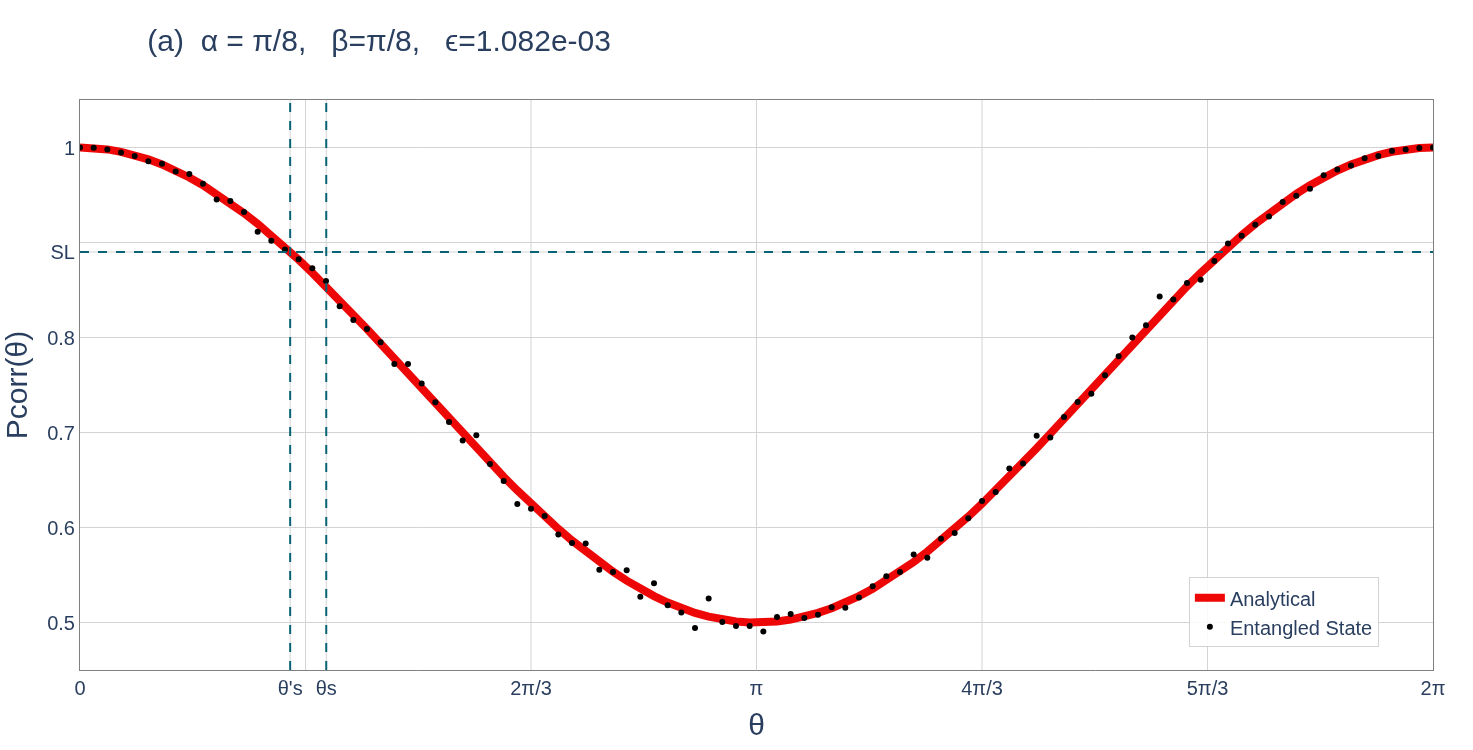

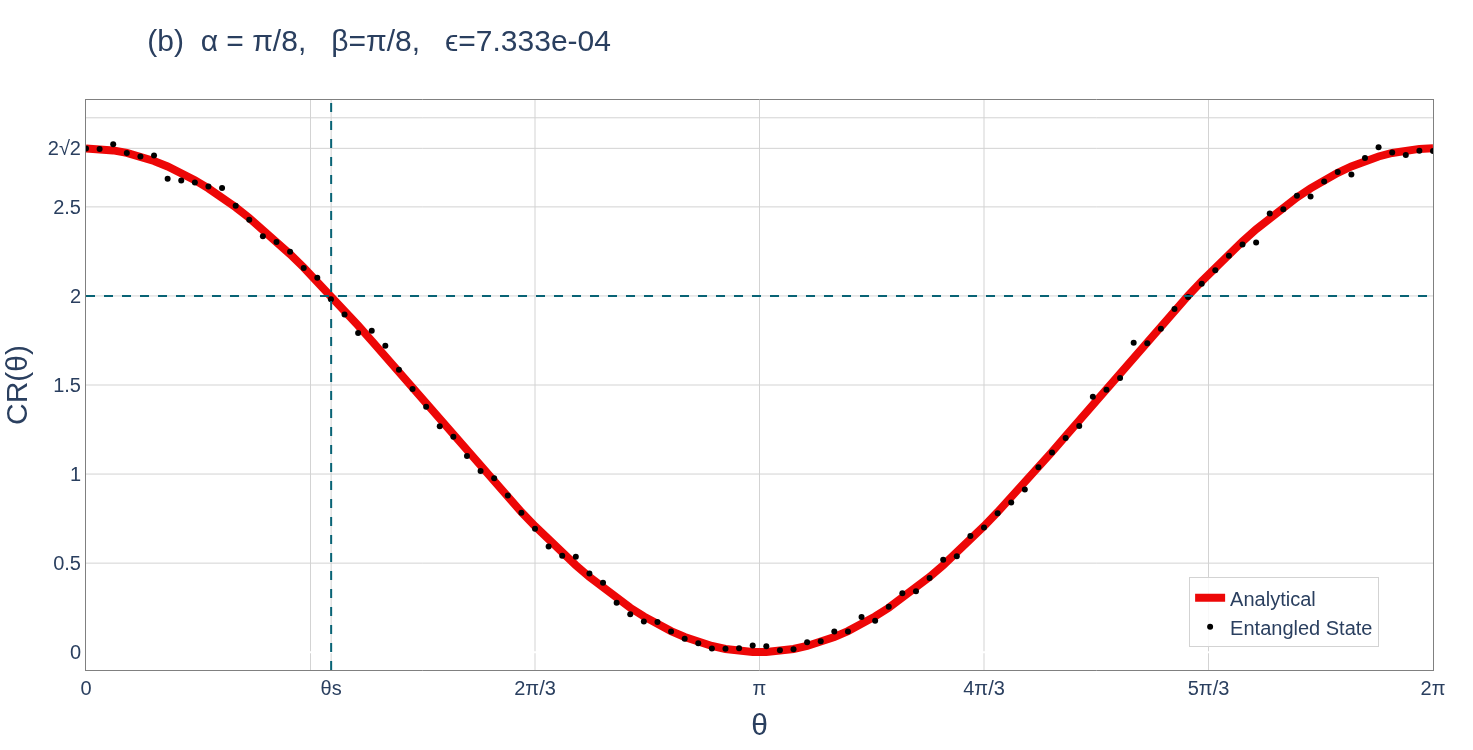

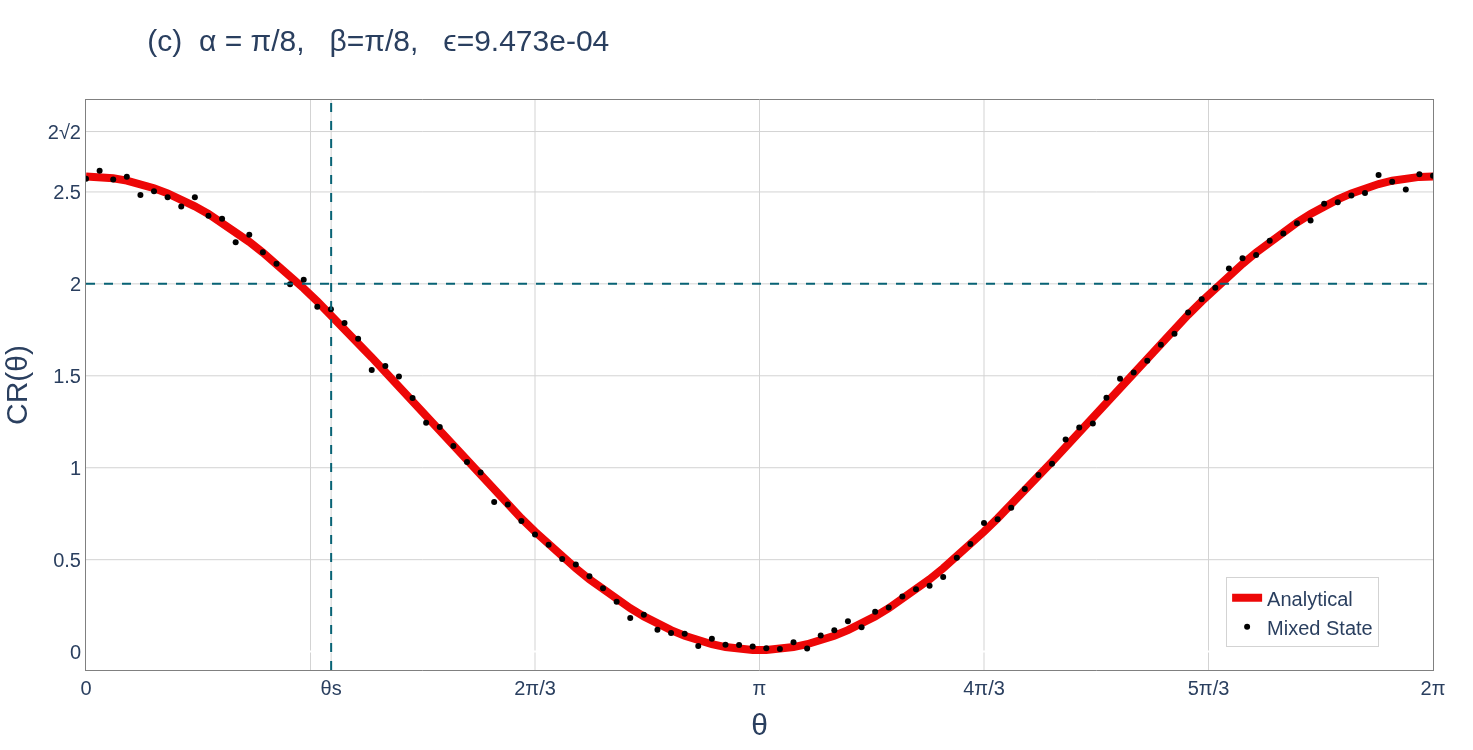

/tmp/ipykernel_36012/48658265.py:2: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/tmp/ipykernel_36012/48658265.py:3: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/tmp/ipykernel_36012/48658265.py:4: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




In [10]:
display(fig_a,fig_b,fig_c)
fig_a.write_image("Fig7a.pdf")
fig_b.write_image("Fig7b.pdf")
fig_c.write_image("Fig7c.pdf")